In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 00 — Data Preprocessing

Loads the raw Kaggle *Home Credit — Credit Risk Model Stability* parquet files and produces a clean tabular dataset with a temporal key (`date_decision`), ready for the rolling-window experiment.

The feature engineering recipe adapts [TabReD's `preprocessing/homecredit.py`](https://github.com/yandex-research/tabred/blob/main/preprocessing/homecredit.py) so the rolling-window study downstream operates on a benchmark-faithful feature matrix. The packaging of the resulting matrix follows this thesis's [Homesite blueprint](../../Homesite_workspace/notebooks/00_data_preprocessing.ipynb) so notebooks 01–04 are near-identical across the three implementations.

Three intentional deviations from TabReD, motivated by the rolling-retraining methodology of this thesis:

- **Per-window categorical encoding (deferred).** This notebook saves raw string categoricals in `X_cat.parquet` and does *not* encode them globally. The methodology requires a single `OrdinalEncoder(min_frequency=1/100)` fitted on each (window, side) using only that window's training rows, then reused unchanged by every bootstrap replica of that side. Fitting per replica would give the same category different integer codes across replicas and inject spurious drift into SHAP / LIME / coefficient comparisons; fitting once globally on the full dataset would leak future categories into early windows. The per-window encoder's output is one-hot expanded for every model so all models see nominal categories rather than monotonic integer codes; SHAP and LIME attributions are aggregated dummy→cat in notebook 03 / 03b so downstream artefacts stay on the original (n_num + n_bin + n_cat) axis. The encoder fit happens in notebook 02 / 02b.
- **Missingness sentinel + per-column indicators.** Every feature column with at least one NaN gets a paired `<col>__missing` int8 indicator. The underlying NaN is then refilled with a sentinel (`-1` for numerics, the literal `'__MISSING__'` for object-dtype categoricals) so that `X.parquet` is NaN-free for downstream `.values.astype(np.float32)` casts. Per-column indicators (rather than a single global missing-count column) are kept deliberately so per-feature missingness shifts remain visible to the drift analysis. Because TabReD's depth-1 / depth-2 aggregations produce paired columns from the same source rows (e.g. `max_X / min_X / mean_X / std_X`) and a `case_id` without records in a relational table is missing all four simultaneously, the resulting `__missing` indicators contain large bit-identical groups. The same structural mechanism also produces bit-identical *value* columns when a source column has at most one non-null record per case_id (then `max_X == min_X == mean_X` and `std_X` is a constant sentinel). Section 7.3 deduplicates bit-identical columns in both `X_bin` and `X_num` so that perfect linear dependencies do not appear in the design matrix downstream. These duplicates would otherwise destabilise the LR solver's Hessian factorisation and inflate gauge-noise across replicas in tree-based and neural attributions. Traceability manifests of merged columns are saved as `bin_dedup_manifest.json` and `num_dedup_manifest.json`.
- **Early case_id subsampling (RAM optimisation).** TabReD subsamples 25% of the rows *after* preprocessing. We subsample case_ids *before* preprocessing, so each depth-1 / depth-2 table is filtered to the subsample case_ids before aggregation. Aggregations are keyed on `case_id`, so each case_id's aggregated features are bit-for-bit identical regardless of subsample order. The only side-effect is that the column-drop statistics in section 5 and the EDA in section 9 see only the subsample; for a 25% subsample this is statistically indistinguishable from TabReD's behaviour.

Two further dataset-specific adaptations, documented at the point of use:

- **Explicit binary feature list.** TabReD's homecredit recipe defines exactly two binaries (`isbidproduct_1095L` and `max_sex_738L == 'F'`). On the post-aggregation feature space, an `nunique == 2` auto-detection rule (as used in the Homesite recipe) would mis-classify many 2-valued numeric aggregates as binaries; we therefore use TabReD's explicit list and document the deviation from the Homesite auto-detection rule in section 6.
- **Table-name prefix on aggregated columns.** Aggregated columns from each relational table are prefixed with the table identifier (e.g. `applprev_1_mean_amount_4527152A`) instead of relying on polars' natural collision suffix. This keeps the source table visible in downstream SHAP / LIME plots and in the drift analysis, at the cost of deviating from TabReD's natural column names.

**Input:** `data/raw/parquet_files/train/*.parquet` (Kaggle *home-credit-credit-risk-model-stability*)  
**Output:**
- `data/processed/X.parquet` — numeric + binary feature matrix, NaN-free, float-castable  
- `data/processed/X_num.parquet` — numeric feature matrix (float32), deduplicated  
- `data/processed/X_bin.parquet` — binary indicator matrix (int8): TabReD binaries + deduplicated `__missing` indicators  
- `data/processed/bin_dedup_manifest.json` — record of which binary columns were merged with which during dedup  
- `data/processed/num_dedup_manifest.json` — record of which numeric columns were merged with which during dedup  
- `data/processed/X_cat.parquet` — raw string categoricals (object); encoded per-window in 02/02b  
- `data/processed/Y.npy` — binary labels (1 = default)  
- `data/processed/meta.parquet` — `[case_id, date_decision]`  
- `data/processed/feature_names.json` — `{'all', 'num', 'bin', 'cat'}` registry  

**Convention:** `'all' == 'num' + 'bin'` matches `X.parquet` column order. `'cat'` is a separate group, loaded only by notebooks that handle categoricals.

In [2]:
import os
import gc
import json
import hashlib
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ───────────────────────────────────────────────────────────────
# WORKSPACE : root folder for all notebook inputs/outputs
# RAW_DIR   : raw Kaggle parquet files (write-once, never modified by this notebook)
# CACHE_DIR : intermediate parquet cache; skips redundant aggregation on re-runs
# PROC_DIR  : final artefacts consumed by downstream notebooks (X, Y, meta, ...)
# FIG_DIR   : EDA figure output directory
WORKSPACE = Path('/content/drive/MyDrive/Thesis/HomeCredit_workspace')
RAW_DIR   = WORKSPACE / 'data' / 'raw'
CACHE_DIR = WORKSPACE / 'data' / 'cache'
PROC_DIR  = WORKSPACE / 'data' / 'processed'
FIG_DIR   = PROC_DIR / 'figures'

for d in [RAW_DIR, CACHE_DIR, PROC_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Locate the parquet train directory. The Kaggle release ships the parquet files
# under a nested folder, so we fall back to a recursive search for train_base.parquet.
_candidates = list(RAW_DIR.rglob('train_base.parquet'))
assert _candidates, (
    f'train_base.parquet not found under {RAW_DIR}. Place the unzipped Kaggle\n'
    f'home-credit-credit-risk-model-stability parquet files anywhere under {RAW_DIR}.'
)
TRAIN_DIR = _candidates[0].parent

# ── Experiment knobs ─────────────────────────────────────────────────
# N_SUBSAMPLE: target case_id count after the early subsample. 25% of the
# 1,526,659 raw case_ids approximately matches TabReD’s 25% subsample.
# CHUNK_SIZE: case_id chunk size for the two largest depth-2 tables.
N_SUBSAMPLE = 381_664
SUBSAMPLE_SEED = 0
CHUNK_SIZE = 50_000

# Reproducibility seed (used for any randomized step further down, e.g. EDA sampling)
np.random.seed(0)

print('Paths OK')
print(f'  TRAIN_DIR     : {TRAIN_DIR}')
print(f'  CACHE_DIR     : {CACHE_DIR}')
print(f'  PROC_DIR      : {PROC_DIR}')
print(f'  FIG_DIR       : {FIG_DIR}')
print(f'  N_SUBSAMPLE   : {N_SUBSAMPLE:,}')
print(f'  SUBSAMPLE_SEED: {SUBSAMPLE_SEED}')
print(f'  CHUNK_SIZE    : {CHUNK_SIZE:,}')

Paths OK
  TRAIN_DIR     : /content/drive/MyDrive/Thesis/HomeCredit_workspace/data/raw/home-credit-credit-risk-model-stability (Unzipped Files)/parquet_files/train
  CACHE_DIR     : /content/drive/MyDrive/Thesis/HomeCredit_workspace/data/cache
  PROC_DIR      : /content/drive/MyDrive/Thesis/HomeCredit_workspace/data/processed
  FIG_DIR       : /content/drive/MyDrive/Thesis/HomeCredit_workspace/data/processed/figures
  N_SUBSAMPLE   : 381,664
  SUBSAMPLE_SEED: 0
  CHUNK_SIZE    : 50,000


## 1. Load base table and subsample case_ids

The Home Credit dataset has one row per loan application (`case_id`, ~1.53 M applications spanning Jan 2019 – Oct 2020) in `train_base.parquet`, with the binary target `target` and the temporal anchor `date_decision`. Around it sit two static (depth-0) tables and twelve relational (depth-1 + depth-2) tables that store credit-bureau, tax, application-history, and other behavioural signals.

We sample `N_SUBSAMPLE` case_ids uniformly at random from the base table and use only these case_ids everywhere downstream. This is the primary RAM optimisation: each relational table is filtered to the subsample case_ids on read, so the in-memory groupby never grows past the subsample size.

Why this is safe: TabReD's aggregations are keyed on `case_id` and never cross case_ids. The per-case_id aggregated features are therefore bit-for-bit identical whether the subsample is taken before or after aggregation. The only side-effect is that the column-drop statistics in section 5 and the EDA in section 9 see only the subsample; for a 25% subsample this is statistically indistinguishable from TabReD's behaviour.

In [3]:
# Load base table — one row per case_id, with target and date_decision.
base = pl.read_parquet(TRAIN_DIR / 'train_base.parquet')
base = base.with_columns([
    pl.col('case_id').cast(pl.Int64),
    pl.col('date_decision').cast(pl.Date),
    pl.col('target').cast(pl.Int8),
])
print(f'train_base raw shape: {base.shape}')

# Subsample case_ids uniformly at random.
if N_SUBSAMPLE is not None and base.shape[0] > N_SUBSAMPLE:
    base = base.sample(n=N_SUBSAMPLE, seed=SUBSAMPLE_SEED, shuffle=True)
    print(f'Subsampled to {base.shape[0]:,} case_ids (seed={SUBSAMPLE_SEED}).')
else:
    print(f'Using full base table: {base.shape[0]:,} case_ids.')

# Sort by date_decision for downstream stability (final sort happens in section 8).
base = base.sort(['date_decision', 'case_id'])
print(f'Date range   : {base["date_decision"].min()} → {base["date_decision"].max()}')
print(f'Positive rate: {base["target"].mean():.4f}')

# Build the case_id filter set used everywhere downstream.
case_id_set = set(base['case_id'].to_list())
print(f'case_id_set size: {len(case_id_set):,}')

train_base raw shape: (1526659, 5)
Subsampled to 381,664 case_ids (seed=0).
Date range   : 2019-01-01 → 2020-10-05
Positive rate: 0.0315
case_id_set size: 381,664


## 2. TabReD aggregation helpers

The aggregation logic follows TabReD’s homecredit preprocessing recipe, with adaptations for the rolling-window setting, memory constraints, and leakage-safe downstream encoding.

Aggregation recipe (verbatim TabReD):

| Suffix | Aggregations |
|---|---|
| `P`, `A`, `T`, `L` | `max`, `min`, `mean`, `std` |
| `M` | `last`, `n_unique`, `first` |
| `D` | `max`, `min`, `mean`, `std` |

In [4]:
def set_table_dtypes(df: pl.LazyFrame) -> pl.LazyFrame:
    """Cast ID columns to Int32, date-like columns (suffix 'D' or named
    'date_decision') to Date, and downcast numerics to the smallest type
    that fits their min/max range. Faithful to TabReD's homecredit.py.
    """
    for col in df.collect_schema().names():
        if col in ('case_id', 'WEEK_NUM', 'num_group1', 'num_group2'):
            df = df.with_columns(pl.col(col).cast(pl.Int32))
        elif col == 'date_decision' or col[-1] == 'D':
            df = df.with_columns(pl.col(col).cast(pl.Date))

    int_types   = (pl.Int8, pl.Int16, pl.Int32, pl.Int64)
    float_types = (pl.Float32, pl.Float64)
    table_min = df.select(pl.col('*').min()).collect(streaming=True)
    table_max = df.select(pl.col('*').max()).collect(streaming=True)

    for col, col_type in df.collect_schema().items():
        c_min = table_min[col].item()
        c_max = table_max[col].item()
        if c_min is None or c_max is None:
            continue
        if col_type in int_types:
            for cand_type, np_info in [(pl.Int8, np.iinfo(np.int8)),
                                        (pl.Int16, np.iinfo(np.int16)),
                                        (pl.Int32, np.iinfo(np.int32)),
                                        (pl.Int64, np.iinfo(np.int64))]:
                if c_min > np_info.min and c_max < np_info.max:
                    df = df.with_columns(pl.col(col).cast(cand_type))
                    break
        elif col_type in float_types:
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df = df.with_columns(pl.col(col).cast(pl.Float32))
    return df


def read_tables_lazy(table_paths) -> pl.LazyFrame:
    """Lazy-concatenate parquet files matching a glob."""
    table_paths = list(table_paths)
    assert table_paths, 'No parquet files matched.'
    return pl.concat([
        pl.scan_parquet(p, low_memory=True, rechunk=True) for p in table_paths
    ], how='vertical_relaxed')


def aggregate_features(df: pl.LazyFrame) -> pl.LazyFrame:
    """TabReD's uniform aggregation recipe: one row per case_id.

    Numeric (P/A/T/L) and date (D) columns get max/min/mean/std; masked
    categorical (M) columns get last/n_unique/first. Sorted by num_group1
    before group-by so 'last' and 'first' are deterministic.

    Implementation note: D-suffixed columns are cast to Int32 (days since
    epoch) before aggregation, because polars no longer supports std() on
    the Date dtype. The subsequent days-since-date_decision conversion in
    section 4 yields the same numeric result whether performed on Dates or
    on day-counts.
    """
    schema = df.collect_schema()
    cols = schema.names()

    # Cast D-suffixed columns to Int32 (days since epoch). Excludes
    # 'date_decision' itself: it is part of the base table and must remain Date.
    date_cols_to_cast = [c for c in cols
                         if c.endswith('D') and c != 'date_decision'
                         and schema[c] == pl.Date]
    if date_cols_to_cast:
        df = df.with_columns([
            pl.col(c).cast(pl.Date).cast(pl.Int32, strict=False)
            for c in date_cols_to_cast
        ])

    exprs = []
    for col in cols:
        if col[-1] in ('P', 'A', 'T', 'L'):
            exprs.extend([
                pl.col(col).max().alias(f'max_{col}'),
                pl.col(col).min().alias(f'min_{col}'),
                pl.col(col).mean().alias(f'mean_{col}'),
                pl.col(col).std().alias(f'std_{col}'),
            ])
    for col in cols:
        if col[-1] == 'M':
            exprs.extend([
                pl.col(col).last().alias(f'last_{col}'),
                pl.col(col).n_unique().alias(f'n_unique_{col}'),
                pl.col(col).first().alias(f'first_{col}'),
            ])
    for col in cols:
        if col[-1] == 'D':
            exprs.extend([
                pl.col(col).max().alias(f'max_{col}'),
                pl.col(col).min().alias(f'min_{col}'),
                pl.col(col).mean().alias(f'mean_{col}'),
                pl.col(col).std().alias(f'std_{col}'),
            ])
    return df.sort('num_group1').group_by('case_id').agg(exprs)


print('Helpers defined.')

Helpers defined.


## 3. Static (depth-0) tables — direct join

The two static tables (`train_static_0_*.parquet` and `train_static_cb_0.parquet`) already have one row per `case_id`, so they join directly without aggregation. Each is filtered to the subsample case_ids before joining to bound RAM. The merged frame is cached as `cache/d0_merged.parquet`.

In [5]:
d0_cache = CACHE_DIR / 'd0_merged.parquet'

if d0_cache.exists():
    print('Loading cached depth-0 merge ...')
    d0 = pl.read_parquet(d0_cache)
    print(f'Loaded: {d0.shape}')
else:
    static_0  = read_tables_lazy(TRAIN_DIR.glob('train_static_0_*.parquet')).pipe(set_table_dtypes)
    static_cb = read_tables_lazy(TRAIN_DIR.glob('train_static_cb_0.parquet')).pipe(set_table_dtypes)

    # Filter to subsample, then materialise — small enough to fit in RAM easily.
    static_0  = static_0.filter(pl.col('case_id').is_in(case_id_set)).collect(streaming=True)
    static_cb = static_cb.filter(pl.col('case_id').is_in(case_id_set)).collect(streaming=True)
    print(f'static_0   : {static_0.shape}')
    print(f'static_cb_0: {static_cb.shape}')

    d0 = (
        base
        .join(static_0,  on='case_id', how='left')
        .join(static_cb, on='case_id', how='left', suffix='_cb')
    )
    print(f'Merged depth-0: {d0.shape}')

    d0.write_parquet(d0_cache)
    print(f'Cached to {d0_cache}')

    del static_0, static_cb
    gc.collect()

Loading cached depth-0 merge ...
Loaded: (381664, 224)


## 4. Aggregate the relational tables and assemble the feature frame

Every relational table is reduced to one row per `case_id` via TabReD's single uniform recipe (`aggregate_features`). For the largest depth-2 tables (`credit_a_2`, `credit_b_2`) we process the case_ids in chunks of `CHUNK_SIZE` to bound peak memory.

After aggregation, every aggregated column is **prefixed with the source table identifier** (e.g. `applprev_1_mean_amount_4527152A`). This keeps the source table visible in downstream SHAP / LIME plots and in the drift analysis, at the cost of deviating from TabReD's natural column names.

The aggregated frames are then outer-joined onto each other on `case_id`, then left-joined onto the depth-0 frame from section 3. Finally, every `D`-suffixed column is converted to *days since `date_decision`* (TabReD's recipe).

Per-table caches at `cache/agg_<prefix>.parquet` allow repeated runs to skip the heavy aggregation.

In [6]:
# Tables to aggregate, in TabReD's order. The third element marks the two
# largest depth-2 tables that should be processed in case_id chunks.
RELATIONAL_GLOBS = [
    ('applprev_1',     'train_applprev_1_*.parquet',           False),
    ('tax_a_1',        'train_tax_registry_a_1.parquet',       False),
    ('tax_b_1',        'train_tax_registry_b_1.parquet',       False),
    ('tax_c_1',        'train_tax_registry_c_1.parquet',       False),
    ('credit_a_1',     'train_credit_bureau_a_1_*.parquet',    False),
    ('credit_b_1',     'train_credit_bureau_b_1.parquet',      False),
    ('other_1',        'train_other_1.parquet',                False),
    ('person_1',       'train_person_1.parquet',               False),
    ('deposit_1',      'train_deposit_1.parquet',              False),
    ('debitcard_1',    'train_debitcard_1.parquet',            False),
    ('credit_a_2',     'train_credit_bureau_a_2_*.parquet',    True),
    ('credit_b_2',     'train_credit_bureau_b_2.parquet',      True),
]


def aggregate_table_one_shot(glob_pattern: str):
    """Filter + dtype + aggregate, all in one polars pipeline."""
    paths = list(TRAIN_DIR.glob(glob_pattern))
    if not paths:
        return None
    lf = read_tables_lazy(paths)
    lf = lf.filter(pl.col('case_id').is_in(case_id_set)).pipe(set_table_dtypes)
    return aggregate_features(lf).collect(streaming=True)


def aggregate_table_chunked(glob_pattern: str, chunk_size: int = CHUNK_SIZE):
    """Aggregate a (large) table in case_id chunks to bound peak memory.

    Each chunk reads the parquet files lazily, filters to that chunk's
    case_ids, applies set_table_dtypes + aggregate_features, then collects.
    Per-chunk results have one row per case_id in the chunk and are
    concatenated at the end — small enough to vertical_relaxed without
    blowing memory.
    """
    paths = list(TRAIN_DIR.glob(glob_pattern))
    if not paths:
        return None

    case_id_list = sorted(case_id_set)
    n_chunks = (len(case_id_list) + chunk_size - 1) // chunk_size
    print(f'    chunked: {n_chunks} chunks of ~{chunk_size:,} case_ids each')

    chunk_results = []
    for chunk_idx in range(n_chunks):
        start = chunk_idx * chunk_size
        end   = min(start + chunk_size, len(case_id_list))
        chunk_ids = set(case_id_list[start:end])

        lf = read_tables_lazy(paths)
        lf = lf.filter(pl.col('case_id').is_in(chunk_ids)).pipe(set_table_dtypes)
        chunk_results.append(aggregate_features(lf).collect(streaming=True))

        if (chunk_idx + 1) % 2 == 0 or chunk_idx == n_chunks - 1:
            print(f'    chunk {chunk_idx + 1}/{n_chunks} done '
                  f'(rows so far: {sum(c.shape[0] for c in chunk_results):,})')

    if not chunk_results:
        return None
    return pl.concat(chunk_results, how='vertical_relaxed')


aggregated_frames = []
for prefix, glob, is_chunked in RELATIONAL_GLOBS:
    cache_path = CACHE_DIR / f'agg_{prefix}.parquet'

    if cache_path.exists():
        print(f'[{prefix}] loading cached aggregate ...')
        agg = pl.read_parquet(cache_path)
        print(f'  shape: {agg.shape}')
    else:
        print(f'[{prefix}] aggregating ({"chunked" if is_chunked else "one-shot"}) ...')
        if is_chunked:
            agg = aggregate_table_chunked(glob)
        else:
            agg = aggregate_table_one_shot(glob)
        if agg is None:
            print(f'  WARNING: no files matched {glob} — skipping.')
            continue
        # Prefix every non-key column with the table name to keep the source
        # table visible in downstream feature-importance / drift analysis.
        agg = agg.rename({c: f'{prefix}_{c}' for c in agg.columns if c != 'case_id'})
        print(f'  shape: {agg.shape}')
        agg.write_parquet(cache_path)
        print(f'  cached to {cache_path}')
        gc.collect()

    aggregated_frames.append(agg)

print(f'\nTotal aggregated tables: {len(aggregated_frames)}')

[applprev_1] loading cached aggregate ...
  shape: (304736, 150)
[tax_a_1] loading cached aggregate ...
  shape: (114458, 12)
[tax_b_1] loading cached aggregate ...
  shape: (37590, 12)
[tax_c_1] loading cached aggregate ...
  shape: (120492, 12)
[credit_a_1] loading cached aggregate ...
  shape: (346275, 298)
[credit_b_1] loading cached aggregate ...
  shape: (9230, 164)
[other_1] loading cached aggregate ...
  shape: (12696, 21)
[person_1] loading cached aggregate ...
  shape: (381664, 133)
[deposit_1] loading cached aggregate ...
  shape: (26144, 13)
[debitcard_1] loading cached aggregate ...
  shape: (27906, 17)
[credit_a_2] loading cached aggregate ...
  shape: (346012, 59)
[credit_b_2] loading cached aggregate ...
  shape: (9214, 13)

Total aggregated tables: 12


In [7]:
# Outer-join aggregated frames first (all small, ~one row per case_id).
print('Joining aggregated frames ...')
d1 = aggregated_frames[0]
for i, other in enumerate(aggregated_frames[1:], start=2):
    d1 = d1.join(other, on='case_id', how='full', coalesce=True)
    print(f'  after join {i}: {d1.shape}')
    gc.collect()

# Join onto the depth-0 frame.
print('\nJoining d0 + d1 ...')
data = d0.join(d1, on='case_id', how='left')
print(f'Full merged frame: {data.shape}')

del d0, d1, aggregated_frames
gc.collect()

# TabReD's date conversion: every D-suffixed column → days since date_decision.
# Implementation note: depth-1 / depth-2 D-columns were already cast to Int32
# (days since epoch) inside aggregate_features so that std() worked. Here we
# subtract date_decision's days-since-epoch from each of those Int32 columns to
# obtain days-since-date_decision, which is numerically identical to TabReD's
# Date - Date → Duration → total_days() conversion.
# Any D-suffixed column that is still pl.Date (e.g. directly from a depth-0
# static table) is converted via the original Date - Date subtraction.
print('\nConverting D-columns to days since date_decision ...')
date_decision_int = pl.col('date_decision').cast(pl.Int32)

schema = data.schema
conversion_exprs = []
n_int_d, n_date_d = 0, 0
for c, dt in schema.items():
    if not c.endswith('D') or c == 'date_decision':
        continue
    if dt == pl.Date:
        conversion_exprs.append(
            (pl.col(c) - pl.col('date_decision')).dt.total_days().cast(pl.Float32).alias(c)
        )
        n_date_d += 1
    elif dt in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                pl.Float32, pl.Float64):
        conversion_exprs.append(
            (pl.col(c).cast(pl.Float32) - date_decision_int.cast(pl.Float32)).alias(c)
        )
        n_int_d += 1

if conversion_exprs:
    data = data.with_columns(conversion_exprs)
print(f'  converted {n_int_d} Int D-columns and {n_date_d} Date D-columns')

Joining aggregated frames ...
  after join 2: (328180, 161)
  after join 3: (333761, 172)
  after join 4: (357135, 183)
  after join 5: (373445, 480)
  after join 6: (373503, 643)
  after join 7: (373514, 663)
  after join 8: (381664, 795)
  after join 9: (381664, 807)
  after join 10: (381664, 823)
  after join 11: (381664, 881)
  after join 12: (381664, 893)

Joining d0 + d1 ...
Full merged frame: (381664, 1116)

Converting D-columns to days since date_decision ...
  converted 128 Int D-columns and 24 Date D-columns


## 5. Drop redundant columns (TabReD's rules)

TabReD's three drop rules, computed on the (subsampled) joined frame:

1. columns with more than 95% null;
2. columns with a single distinct non-null value;
3. string columns with more than 50 distinct values.

Plus TabReD's three hard-coded leftovers `min_sex_738L`, `MONTH`, `WEEK_NUM`. These are dropped from the feature set and **not** preserved in `meta`: the Homesite / Shoppers blueprint keeps `meta` minimal (`[id, date]`); anything time-derived is recomputable from `date_decision` if a downstream notebook needs it.

In [8]:
print('Computing drop statistics ...')
many_nulls = data.select(pl.col('*').is_null().mean().gt(0.95))
n_unique   = data.select(pl.col('*').drop_nulls().n_unique())

drop_cols = [
    c for c, dtype in data.schema.items()
    if (many_nulls[c].item() or
        n_unique[c].item() == 1 or
        (dtype == pl.String and n_unique[c].item() > 50))
]

# Defensive: never drop the columns we structurally need.
must_keep = {'case_id', 'date_decision', 'target'}
drop_cols = [c for c in drop_cols if c not in must_keep]
print(f'Dropping {len(drop_cols)} columns by TabReD\'s rules')

data = data.drop(drop_cols)

# TabReD's hard-coded leftovers. We search by suffix because section-4 prefixed
# the depth-1 columns: 'min_sex_738L' becomes e.g. 'person_1_min_sex_738L'.
# 'MONTH' and 'WEEK_NUM' come from the static tables and are unprefixed.
leftover_targets = ['min_sex_738L', 'MONTH', 'WEEK_NUM']
leftover_drops = [
    c for c in data.columns
    if any(c == t or c.endswith('_' + t) for t in leftover_targets)
]
if leftover_drops:
    data = data.drop(leftover_drops)
    print(f'Dropped leftovers: {leftover_drops}')
print(f'After all drops: {data.shape}')

Computing drop statistics ...
Dropping 393 columns by TabReD's rules
Dropped leftovers: ['MONTH', 'WEEK_NUM', 'person_1_min_sex_738L']
After all drops: (381664, 720)


## 6. Feature triage

Partition the cleaned feature columns into three groups using TabReD's homecredit recipe:

- **Binary** — `isbidproduct_1095L` (already 0/1) plus a derived flag `max_sex_738L_eq_F = (max_sex_738L == 'F')`. Stored as `int8`. The original `max_sex_738L` string column is excluded from the categorical block since it is consumed entirely by the derived flag.
- **Categorical** — every remaining `pl.String`-typed column (these survived the >50-distinct-values drop in section 5). Stored as raw strings; a single `OrdinalEncoder(min_frequency=1/100)` is fitted per (window, side) in notebook 02/02b.
- **Numeric** — everything else (numerics + booleans, excluding ids / target / date / binaries). Stored as `float32`.

Two intentional deviations from the Homesite blueprint, both flagged in markdown at the point of use:

1. **Explicit binary list rather than `nunique == 2` auto-detection.** The (subsampled) post-aggregation feature space contains many 2-valued numeric aggregates (e.g. `max_X` where `X` took only two values in the sampled records). Auto-detection would mis-classify these as binaries and route them away from the numeric block. TabReD's recipe defines the binary set explicitly, so we use it verbatim.
2. **Per-column missingness handling and bit-identical dedup are kept verbatim from Homesite** (section 7 below). HomeCredit's depth-1 / depth-2 aggregations produce paired columns from the same source rows, so the resulting `__missing` indicators contain large bit-identical groups that the dedup compresses substantially.

Section 7 then handles missingness, builds the three blocks, and deduplicates bit-identical binary indicators.

In [9]:
# Materialise the explicit TabReD binaries as int8 columns. We search for the
# source columns by suffix because section 4 prefixed the depth-1 columns.
isbid_candidates = [c for c in data.columns if c == 'isbidproduct_1095L'
                    or c.endswith('_isbidproduct_1095L')]
sex_candidates   = [c for c in data.columns if c.endswith('max_sex_738L')
                    and not c.endswith('first_max_sex_738L')
                    and not c.endswith('last_max_sex_738L')
                    and not c.endswith('n_unique_max_sex_738L')]
# Exclude any aggregation-of-aggregation collisions; the TabReD recipe targets
# the original `max_sex_738L` aggregate (which becomes `<table>_max_sex_738L`
# after the section-4 prefix rename).

assert isbid_candidates, "Could not locate 'isbidproduct_1095L' in the merged frame."
assert sex_candidates,   "Could not locate '*max_sex_738L' in the merged frame."
isbid_src = isbid_candidates[0]
sex_src   = sex_candidates[0]
assert len(isbid_candidates) == 1
assert len(sex_candidates) == 1
print(f'Binary source columns: {isbid_src!r}, {sex_src!r}')

# Build the two binary feature columns.
data = data.with_columns([
    pl.col(isbid_src).cast(pl.Int8).alias('isbidproduct_1095L'),
    pl.col(sex_src).eq('F').cast(pl.Int8).alias('max_sex_738L_eq_F'),
])
bin_names = ['isbidproduct_1095L', 'max_sex_738L_eq_F']

# Drop the original sex string column — it is fully captured by the derived flag.
# Drop the original isbidproduct column only if its name differs from the canonical
# binary name (i.e. it was prefixed and is now a duplicate).
to_drop = [sex_src]
if isbid_src != 'isbidproduct_1095L':
    to_drop.append(isbid_src)
data = data.drop(to_drop)
print(f'Dropped source columns: {to_drop}')

# Convert to pandas for the missingness / triage / dedup logic that follows.
# The polars pipeline ends here; sections 7+ are direct adaptations of the
# Homesite blueprint and are easier to express in pandas.
print('\nMaterialising to pandas ...')
df = data.to_pandas()
df['date_decision'] = pd.to_datetime(df['date_decision'])
del data
gc.collect()
print(f'pandas frame: {df.shape}, '
      f'mem={df.memory_usage(deep=True).sum()/1e9:.2f} GB')

Binary source columns: 'isbidproduct_1095L', 'person_1_max_sex_738L'
Dropped source columns: ['person_1_max_sex_738L']

Materialising to pandas ...
pandas frame: (381664, 720), mem=2.67 GB


In [10]:
# ── 6.2 Partition cleaned feature columns into binary / categorical / numeric ──
# Target, ID, and timestamp are not features.
exclude = {'case_id', 'date_decision', 'target'}
feature_cols = [c for c in df.columns if c not in exclude]

# Binary block is fixed by TabReD's recipe (set above).
bin_cols_raw = list(bin_names)

# Categorical: object-dtype columns that are not in the binary block.
cat_cols = [c for c in feature_cols
            if df[c].dtype == object and c not in bin_cols_raw]

# Numeric: everything else (numerics + booleans).
num_cols_raw = [c for c in feature_cols
                if c not in bin_cols_raw and c not in cat_cols]

print(f'Binary cols      : {len(bin_cols_raw)}')
print(f'Categorical cols : {len(cat_cols)}')
print(f'Numeric cols     : {len(num_cols_raw)}')
print()
print('Categorical column names (first 20):')
print(cat_cols[:20])
if len(cat_cols) > 20:
    print(f'... ({len(cat_cols) - 20} more)')

Binary cols      : 2
Categorical cols : 90
Numeric cols     : 625

Categorical column names (first 20):
['cardtype_51L', 'credtype_322L', 'disbursementtype_67L', 'equalitydataagreement_891L', 'inittransactioncode_186L', 'lastapprcommoditycat_1041M', 'lastrejectcommoditycat_161M', 'lastrejectreason_759M', 'lastrejectreasonclient_4145040M', 'lastst_736L', 'opencred_647L', 'twobodfilling_608L', 'description_5085714M', 'education_1103M', 'education_88M', 'maritalst_385M', 'maritalst_893M', 'requesttype_4525192L', 'applprev_1_max_credacc_status_367L', 'applprev_1_min_credacc_status_367L']
... (70 more)


## 7. Missingness handling, block assembly, and dedup

Direct port of the Homesite blueprint's section 4 (missingness + triage + dedup), applied to the HomeCredit feature space.

1. Build a `<col>__missing` int8 indicator for every feature column with at least one NaN.
2. Fill the underlying NaN with a sentinel: `-1` for numerics, the literal `'__MISSING__'` for object dtype.
3. Build `X_num`, `X_bin`, `X_cat` blocks.
4. Deduplicate bit-identical columns in both `X_num` and `X_bin`. For `X_bin` most duplicates are paired indicators from the same source row (e.g. `applprev_1_max_X__missing` and `applprev_1_min_X__missing`). For `X_num` duplicates appear when a relational source column has at most one non-null record per case_id: then `max_X == min_X == mean_X` by definition for groups of size 1, and `std_X` is constant `-1` after the section-5 / section-7.1 sentinel fill (and is therefore already dropped by section 5). Removing the redundant columns avoids perfect linear dependencies in the design matrix.
5. Sanity checks on the deduplicated state.

In [11]:
# ── 7.1 Missingness indicators ─────────────────────────────────────────────────────
# Create a `<col>__missing` int8 indicator for every column with at least
# one NaN, then fill the underlying NaN with a sentinel: `-1` for numerics
# and the literal `'__MISSING__'` for object-dtype columns. The indicator
# carries the missingness bit; the sentinel keeps `X.parquet` NaN-free for
# downstream `.values.astype(np.float32)` casts.
candidate_cols = [c for c in df.columns if c not in exclude]
cols_with_na = [c for c in candidate_cols if df[c].isna().any()]

print(f'Columns with NaN to indicate: {len(cols_with_na)}')
for c in cols_with_na[:15]:
    rate = df[c].isna().mean()
    print(f'  {c:60s}  NaN rate = {rate:.4f}')
if len(cols_with_na) > 15:
    print(f'  ... ({len(cols_with_na) - 15} more)')

missing_indicators = pd.DataFrame({
    f'{c}__missing': df[c].isna().astype(np.int8).values
    for c in cols_with_na
}, index=df.index)

for c in cols_with_na:
    if df[c].dtype == object:
        df[c] = df[c].fillna('__MISSING__')
    else:
        df[c] = df[c].fillna(-1)

print(f'\nMissingness handled. Indicator matrix shape: {missing_indicators.shape}')

Columns with NaN to indicate: 641
  actualdpdtolerance_344P                                       NaN rate = 0.2754
  amtinstpaidbefduel24m_4187115A                                NaN rate = 0.3691
  annuitynextmonth_57A                                          NaN rate = 0.0000
  avgdbddpdlast24m_3658932P                                     NaN rate = 0.4026
  avgdbddpdlast3m_4187120P                                      NaN rate = 0.6218
  avgdbdtollast24m_4525197P                                     NaN rate = 0.6378
  avgdpdtolclosure24_3658938P                                   NaN rate = 0.3074
  avginstallast24m_3658937A                                     NaN rate = 0.4103
  avglnamtstart24m_4525187A                                     NaN rate = 0.8937
  avgmaxdpdlast9m_3716943P                                      NaN rate = 0.4966
  avgoutstandbalancel6m_4187114A                                NaN rate = 0.5519
  avgpmtlast12m_4525200A                                        

In [17]:
# ── 7.2.1 X_bin ───────────────────────────────────────────────────────────────────────────
# TabReD binaries (already int8 from section 6) plus the per-column `__missing`
# indicators (also int8) concatenated at the end.
X_bin_raw = df[bin_cols_raw].astype(np.int8)
X_bin = pd.concat(
    [X_bin_raw.reset_index(drop=True),
     missing_indicators.reset_index(drop=True)],
    axis=1,
)

# ── 7.2.2 X_num ───────────────────────────────────────────────────────────────────────────
# Numeric features (float32) plus the 4 calendar features derived from
# date_decision. We use 4 features (incl. month) for cross-implementation
# consistency with the Homesite blueprint, deviating from TabReD's homecredit
# recipe which uses 3 features (no month). The minor redundancy between
# day_of_year and month is accepted as the price of consistency.
calendar = pd.DataFrame({
    'day_of_week':  df['date_decision'].dt.weekday.astype(np.int16).values,
    'day_of_month': df['date_decision'].dt.day.astype(np.int16).values,
    'day_of_year':  df['date_decision'].dt.day_of_year.astype(np.int16).values,
    'month':        df['date_decision'].dt.month.astype(np.int16).values,
}, index=df.index)

X_num = pd.concat(
    [df[num_cols_raw].astype(np.float32).reset_index(drop=True),
     calendar.astype(np.float32).reset_index(drop=True)],
    axis=1,
)

# ── 7.2.3 X_cat ───────────────────────────────────────────────────────────────────────────
# Raw string categoricals are saved unencoded; the per-(window, side)
# OrdinalEncoder is fitted in 02 / 02b. See the design note at the top of
# the notebook for why encoding is deferred.
#
# We coerce every cell to its string representation so each column has a single
# leaf type. NaN was already replaced with `'__MISSING__'` in section 7.1, so
# the only effect of this cast is to normalise bool/numeric cells to strings;
# the per-window OrdinalEncoder in 02/02b consumes strings either way.
X_cat = df[cat_cols].reset_index(drop=True)
for c in X_cat.columns:
    X_cat[c] = X_cat[c].astype(str).astype('object')

print(f'X_num: {X_num.shape}  ({len(num_cols_raw)} raw numeric + 4 calendar)')
print(f'X_bin: {X_bin.shape}  ({len(bin_cols_raw)} TabReD binary + {missing_indicators.shape[1]} __missing indicators)')
print(f'X_cat: {X_cat.shape}  (raw strings)')

X_num: (381664, 629)  (625 raw numeric + 4 calendar)
X_bin: (381664, 643)  (2 TabReD binary + 641 __missing indicators)
X_cat: (381664, 90)  (raw strings)


In [18]:
# ── 7.3 Deduplicate bit-identical columns ───────────────────────────────────────────────────
# Strategy: hash each column's raw bytes (preserving its native dtype),
# keep the first occurrence per hash group, drop the rest. Save a manifest
# mapping every dropped column to its kept representative for downstream
# traceability and reproducibility.
#
# Both X_bin and X_num are deduped. X_bin duplicates come primarily from the
# paired `<col>__missing` indicators: TabReD's depth-1 / depth-2 aggregations
# emit max/min/mean/std for the same source rows, so a case_id without records
# in a relational table is missing all four simultaneously, producing
# bit-identical missingness indicators.
#
# X_num duplicates have the analogous structural cause: when a relational
# source column has at most one non-null record per case_id across the whole
# dataset, max(x) == min(x) == mean(x) by definition (groups of size 1), and
# std(x) is NaN → filled with the numeric sentinel -1 → constant column →
# already dropped by section 5's "single distinct value" rule. The surviving
# max/min/mean trio is therefore three bit-identical columns. Dropping the
# duplicates removes perfect linear dependencies that would otherwise
# destabilise the LR solver's Hessian factorisation and inflate gauge-noise
# across replicas in tree-based and neural attributions (same rationale as
# the binary dedup).
def _col_hash(values: np.ndarray) -> str:
    """MD5 of the column's raw bytes in its native dtype.
    int8 0/1 columns differ in byte representation from float32 columns
    of the same logical content, so cross-block (num vs bin) hash
    collisions are essentially impossible — exactly the behaviour we want."""
    return hashlib.md5(values.tobytes()).hexdigest()

def _find_dup_groups(df_block: pd.DataFrame):
    """Return (keep_cols, drop_cols, group_map) over the columns of `df_block`.
    group_map[kept_col] = list of dropped columns that hashed to the same value.
    """
    seen: dict[str, str] = {}     # hash → kept column name (first seen)
    group_map: dict[str, list] = {}
    keep_cols, drop_cols = [], []
    for col in df_block.columns:
        h = _col_hash(df_block[col].values)
        if h in seen:
            kept = seen[h]
            group_map[kept].append(col)
            drop_cols.append(col)
        else:
            seen[h] = col
            group_map[col] = []
            keep_cols.append(col)
    return keep_cols, drop_cols, group_map


def _save_dedup_manifest(path, keep_cols, drop_cols, group_map):
    n_groups = sum(1 for dups in group_map.values() if dups)
    manifest = {
        'group_count': int(n_groups),
        'redundant_column_count': int(len(drop_cols)),
        'kept_columns': list(keep_cols),
        'dropped_to_kept': {
            dropped: kept
            for kept, dups in group_map.items()
            for dropped in dups
        },
    }
    with open(path, 'w') as f:
        json.dump(manifest, f, indent=2)
    return n_groups


# ── Numeric block ──────────────────────────────────────────────────────────────────────────
_num_keep, _num_drop, _num_groups = _find_dup_groups(X_num)
_n_num_groups = sum(1 for dups in _num_groups.values() if dups)
print(f'X_num: {_n_num_groups} duplicate hash-groups covering {len(_num_drop)} '
      f'redundant columns.')

shown = 0
for kept, dups in _num_groups.items():
    if not dups:
        continue
    preview = dups[:4] + (['...'] if len(dups) > 4 else [])
    print(f'  kept "{kept}", dropped: {preview}')
    shown += 1
    if shown >= 10:
        break
if _n_num_groups > 10:
    print(f'  ... ({_n_num_groups - 10} more groups omitted from log)')

X_num = X_num.loc[:, _num_keep].reset_index(drop=True)
_save_dedup_manifest(PROC_DIR / 'num_dedup_manifest.json',
                     _num_keep, _num_drop, _num_groups)
print(f'X_num shape after dedup: {X_num.shape}')
print(f'Manifest saved to: {PROC_DIR / "num_dedup_manifest.json"}')

# ── Binary block ───────────────────────────────────────────────────────────────────────────
_bin_keep, _bin_drop, _bin_groups = _find_dup_groups(X_bin)
n_groups = sum(1 for dups in _bin_groups.values() if dups)
print(f'\nX_bin: {n_groups} duplicate hash-groups covering {len(_bin_drop)} '
      f'redundant columns.')

# Print a few examples for the run log so the dedup is not silent.
shown = 0
for kept, dups in _bin_groups.items():
    if not dups:
        continue
    preview = dups[:4] + (['...'] if len(dups) > 4 else [])
    print(f'  kept "{kept}", dropped: {preview}')
    shown += 1
    if shown >= 10:
        break
if n_groups > 10:
    print(f'  ... ({n_groups - 10} more groups omitted from log)')

# Apply the dedup to X_bin.
X_bin = X_bin.loc[:, _bin_keep].reset_index(drop=True)

# Persist manifest for traceability + post-hoc verification.
_save_dedup_manifest(PROC_DIR / 'bin_dedup_manifest.json',
                     _bin_keep, _bin_drop, _bin_groups)

print(f'\nX_bin shape after dedup: {X_bin.shape}')
print(f'Manifest saved to: {PROC_DIR / "bin_dedup_manifest.json"}')

X_num: 17 duplicate hash-groups covering 24 redundant columns.
  kept "eir_270L", dropped: ['interestrate_311L']
  kept "lastapplicationdate_877D", dropped: ['applprev_1_max_creationdate_885D']
  kept "days360_512L", dropped: ['numberofqueries_373L']
  kept "applprev_1_max_pmtnum_8L", dropped: ['applprev_1_max_tenor_203L']
  kept "applprev_1_min_pmtnum_8L", dropped: ['applprev_1_min_tenor_203L']
  kept "applprev_1_mean_pmtnum_8L", dropped: ['applprev_1_mean_tenor_203L']
  kept "applprev_1_std_pmtnum_8L", dropped: ['applprev_1_std_tenor_203L']
  kept "tax_a_1_max_recorddate_4527225D", dropped: ['tax_a_1_min_recorddate_4527225D', 'tax_a_1_mean_recorddate_4527225D']
  kept "credit_a_1_max_debtoutstand_525A", dropped: ['credit_a_1_min_debtoutstand_525A', 'credit_a_1_mean_debtoutstand_525A']
  kept "credit_a_1_max_debtoverdue_47A", dropped: ['credit_a_1_min_debtoverdue_47A', 'credit_a_1_mean_debtoverdue_47A']
  ... (7 more groups omitted from log)
X_num shape after dedup: (381664, 605)
Mani

In [19]:
# ── 7.4 Sanity checks ──────────────────────────────────────────────────────────────────────
assert not X_num.isna().any().any(), 'X_num still has NaN!'
assert not X_bin.isna().any().any(), 'X_bin still has NaN!'
assert all(X_cat[c].dtype == object for c in X_cat.columns), 'X_cat must be object dtype'
assert not X_cat.isna().any().any(), 'X_cat still has NaN!'

# Group exclusivity: no feature name appears in more than one group.
_num_set, _bin_set, _cat_set = set(X_num.columns), set(X_bin.columns), set(X_cat.columns)
assert _num_set.isdisjoint(_bin_set), 'num/bin overlap'
assert _num_set.isdisjoint(_cat_set), 'num/cat overlap'
assert _bin_set.isdisjoint(_cat_set), 'bin/cat overlap'

# Spot-check that every numeric column is finite (sentinel-fill leaves no inf/nan).
_arr = X_num.values.astype(np.float32)
assert np.isfinite(_arr).all(), 'X_num contains non-finite values!'

print('Sanity checks passed.')
print(f'  X_num NaN count : {int(X_num.isna().sum().sum())}')
print(f'  X_bin NaN count : {int(X_bin.isna().sum().sum())}')
print(f'  X_cat NaN count : {int(X_cat.isna().sum().sum())}')
print(f'  X_cat dtypes    : {sorted({str(d) for d in X_cat.dtypes})}')

Sanity checks passed.
  X_num NaN count : 0
  X_bin NaN count : 0
  X_cat NaN count : 0
  X_cat dtypes    : ['object']


## 8. Assemble and save final dataset

In [20]:
# Final chronological sort with case_id as deterministic tiebreaker.
_order = df[['date_decision', 'case_id']].reset_index(drop=True).sort_values(
    ['date_decision', 'case_id'], kind='mergesort').index.values
X_num = X_num.iloc[_order].reset_index(drop=True)
X_bin = X_bin.iloc[_order].reset_index(drop=True)
X_cat = X_cat.iloc[_order].reset_index(drop=True)
df    = df.iloc[_order].reset_index(drop=True)

# X = X_num + X_bin; X_cat is saved separately so downstream can apply per-window encoding.
X = pd.concat([X_num, X_bin], axis=1)
Y = df['target'].astype(np.int8).values

num_feature_names = list(X_num.columns)
bin_feature_names = list(X_bin.columns)
cat_feature_names = list(X_cat.columns)
feature_names     = num_feature_names + bin_feature_names  # 'all' == 'num' + 'bin'

# Build meta last so it picks up the same row order.
meta = pd.DataFrame({
    'case_id':       df['case_id'].astype(np.int64).values,
    'date_decision': df['date_decision'].values,
})

assert list(X.columns) == feature_names, 'X column order mismatch with feature_names'
assert len(X) == len(Y) == len(meta) == len(X_cat), 'Row count mismatch!'
assert not X.isna().any().any(), 'NaN values in X!'

print(f'X     : {X.shape}')
print(f'X_num : {X_num.shape}')
print(f'X_bin : {X_bin.shape}')
print(f'X_cat : {X_cat.shape}')
print(f'Y     : {Y.shape}  positives={int(Y.sum()):,} ({Y.mean():.3%})')
print(f'meta  : {meta.shape}')

X     : (381664, 823)
X_num : (381664, 605)
X_bin : (381664, 218)
X_cat : (381664, 90)
Y     : (381664,)  positives=12,010 (3.147%)
meta  : (381664, 2)


In [21]:
# ── Save artefacts ────────────────────────────────────────────────────────────────────────
X.to_parquet(PROC_DIR / 'X.parquet',     index=False)
X_num.to_parquet(PROC_DIR / 'X_num.parquet', index=False)
X_bin.to_parquet(PROC_DIR / 'X_bin.parquet', index=False)
X_cat.to_parquet(PROC_DIR / 'X_cat.parquet', index=False)
np.save(PROC_DIR / 'Y.npy', Y)
meta.to_parquet(PROC_DIR / 'meta.parquet', index=False)

with open(PROC_DIR / 'feature_names.json', 'w') as f:
    json.dump({
        'all': feature_names,         # == num + bin (matches X.parquet column order)
        'num': num_feature_names,
        'bin': bin_feature_names,
        'cat': cat_feature_names,     # separate group, lives in X_cat.parquet
    }, f, indent=2)

print('Saved:')
for fname in ['X.parquet', 'X_num.parquet', 'X_bin.parquet', 'X_cat.parquet',
              'Y.npy', 'meta.parquet', 'feature_names.json',
              'bin_dedup_manifest.json', 'num_dedup_manifest.json']:
    p = PROC_DIR / fname
    print(f'  {fname:<25s} {p.stat().st_size / 1e6:8.2f} MB')

Saved:
  X.parquet                   265.12 MB
  X_num.parquet               257.25 MB
  X_bin.parquet                 7.86 MB
  X_cat.parquet                 7.72 MB
  Y.npy                         0.38 MB
  meta.parquet                  1.83 MB
  feature_names.json            0.07 MB
  bin_dedup_manifest.json       0.05 MB
  num_dedup_manifest.json       0.03 MB


## 9. Verification

Reload all artefacts from disk and re-check the contract that downstream notebooks rely on:

- Row counts match across `X`, `X_num`, `X_bin`, `X_cat`, `Y`, `meta`.
- `X.parquet` columns exactly match `feature_names['num'] + feature_names['bin']` in order.
- `X.parquet` has zero NaN (so `.values.astype(np.float32)` works without further imputation).
- `meta['date_decision']` is `datetime64[ns]`, no NaN, monotonic non-decreasing.
- `feature_names` groups are pairwise disjoint.
- `X_cat.parquet` contains only object-dtype columns (raw strings, ready for the per-window encoder fit in 02/02b).

In [22]:
X_check     = pd.read_parquet(PROC_DIR / 'X.parquet')
X_num_check = pd.read_parquet(PROC_DIR / 'X_num.parquet')
X_bin_check = pd.read_parquet(PROC_DIR / 'X_bin.parquet')
X_cat_check = pd.read_parquet(PROC_DIR / 'X_cat.parquet')
Y_check     = np.load(PROC_DIR / 'Y.npy')
meta_check  = pd.read_parquet(PROC_DIR / 'meta.parquet')

with open(PROC_DIR / 'feature_names.json') as f:
    fn_check = json.load(f)

n = X_check.shape[0]
assert X_num_check.shape[0] == n and X_bin_check.shape[0] == n
assert X_cat_check.shape[0] == n
assert Y_check.shape[0] == n and meta_check.shape[0] == n

# X column order matches feature_names['all']
assert list(X_check.columns) == fn_check['all'], 'X column order does not match feature_names["all"]'
# 'all' is exactly num + bin
assert fn_check['all'] == fn_check['num'] + fn_check['bin'], \
    "feature_names['all'] must equal feature_names['num'] + feature_names['bin']"
# Groups are pairwise disjoint
assert set(fn_check['num']).isdisjoint(fn_check['bin'])
assert set(fn_check['num']).isdisjoint(fn_check['cat'])
assert set(fn_check['bin']).isdisjoint(fn_check['cat'])

# Zero NaN in X
assert not X_check.isna().any().any(), 'X.parquet contains NaN'

# meta integrity
assert pd.api.types.is_datetime64_any_dtype(meta_check['date_decision'])
assert not meta_check['date_decision'].isna().any()
assert meta_check['date_decision'].is_monotonic_increasing, 'date_decision is not monotonic non-decreasing'

# X_cat is all object (raw strings), no NaN
assert all(X_cat_check[c].dtype == object for c in X_cat_check.columns), 'X_cat must be all-object'
assert not X_cat_check.isna().any().any(), 'X_cat.parquet contains NaN'

# Spot-check the X.values.astype(np.float32) cast that downstream training/explanation notebooks rely on.
X_arr = X_check.values.astype(np.float32)
assert X_arr.dtype == np.float32 and not np.isnan(X_arr).any() and np.isfinite(X_arr).all()

print(f'X      : {X_check.shape}  ({len(fn_check["num"])} num + {len(fn_check["bin"])} bin)')
print(f'X_cat  : {X_cat_check.shape}  (raw strings)')
print(f'Y      : {Y_check.shape}  positives={int(Y_check.sum()):,} ({Y_check.mean():.3%})')
print(f'meta   : {meta_check.shape}')
print(f'Date range: {meta_check["date_decision"].min()} → {meta_check["date_decision"].max()}')

# Dedup manifest sanity check.
manifest_path = PROC_DIR / 'bin_dedup_manifest.json'
assert manifest_path.exists(), 'bin_dedup_manifest.json missing'
with open(manifest_path) as f:
    manifest = json.load(f)
# Every "kept" column listed in the manifest must still be in X.
assert all(c in fn_check['bin'] for c in manifest['kept_columns']), \
    'Some manifest-kept columns are missing from X_bin'
# No "dropped" column should still be in X.
assert not any(c in fn_check['bin'] for c in manifest['dropped_to_kept']), \
    'Some manifest-dropped columns are still in X_bin'
print(f'Dedup manifest verified: {manifest["group_count"]} groups, '
      f'{manifest["redundant_column_count"]} columns merged.')

print('All checks passed.')

X      : (381664, 823)  (605 num + 218 bin)
X_cat  : (381664, 90)  (raw strings)
Y      : (381664,)  positives=12,010 (3.147%)
meta   : (381664, 2)
Date range: 2019-01-01 00:00:00 → 2020-10-05 00:00:00
Dedup manifest verified: 108 groups, 425 columns merged.
All checks passed.


---
## 10. Exploratory Data Analysis

> **Goal of this section:** build intuition about the Home Credit default-risk dataset before modelling and confirm that the temporal field, class balance, and feature matrix all look sensible for the rolling-window experiment.

### What is this dataset?

This is the Kaggle *Home Credit — Credit Risk Model Stability* challenge (2024). Home Credit is a non-banking consumer lender that issues short-term loans, mostly to clients with limited credit history. The dataset has one row per loan application (`case_id`), spanning Jan 2019 – Oct 2020, with a binary target indicating whether the client defaulted within a downstream observation window.

**Prediction task:** Binary classification — given anonymised application, person, credit-bureau, tax-registry, and product-history features, predict whether the loan will default.

**Field families** (after section-4 prefixing):

| Prefix | Source | Meaning |
|---|---|---|
| (no prefix) | `train_static_0_*` / `train_static_cb_0` / `train_base` | one-row-per-application application/cb static features |
| `applprev_1_*` | `train_applprev_1_*` | aggregated previous applications |
| `tax_a_1_*`, `tax_b_1_*`, `tax_c_1_*` | `train_tax_registry_*_1` | aggregated tax-registry data |
| `credit_a_1_*`, `credit_b_1_*` | `train_credit_bureau_*_1` | aggregated depth-1 credit-bureau data |
| `credit_a_2_*`, `credit_b_2_*` | `train_credit_bureau_*_2` | aggregated depth-2 credit-bureau data |
| `other_1_*` | `train_other_1` | aggregated 'other' table |
| `person_1_*` | `train_person_1` | aggregated person-level data |
| `deposit_1_*`, `debitcard_1_*` | `train_deposit_1`, `train_debitcard_1` | aggregated deposit / debit-card data |

TRAINING SET OVERVIEW (subsampled)
Total applications        : 381,664
Unique case_id values     : 381,664
Date range                : 2019-01-01 → 2020-10-05
Positive (default) rate   : 3.147%
Numeric features          : 605
Binary features           : 218
Categorical features      : 90

LABEL DISTRIBUTION
-----------------------------------
  No default (0)      :  369,654  (96.85 %)
  Default (1)         :   12,010  (3.15 %)

Class imbalance ratio  : 30.8:1  (negative : positive)

→ The dataset is heavily imbalanced (~97 % no-default vs ~3 % default).
  The training notebooks (02 / 02b) handle this by fitting every model
  with balanced sample weights (w_c = n / (2 * n_c)) computed per training
  window/side; PR-AUC is reported as the primary metric and is evaluated
  unweighted on the common evaluation slice.


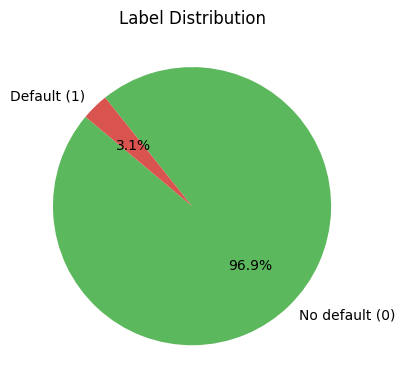

In [23]:
# ── 10.1 Training set overview ───────────────────────────────────────────────────────────
print('=' * 60)
print('TRAINING SET OVERVIEW (subsampled)')
print('=' * 60)
print(f'Total applications        : {len(df):,}')
print(f'Unique case_id values     : {df["case_id"].nunique():,}')
print(f'Date range                : {df["date_decision"].min().date()} → {df["date_decision"].max().date()}')
print(f'Positive (default) rate   : {df["target"].mean():.3%}')
print(f'Numeric features          : {X_num.shape[1]}')
print(f'Binary features           : {X_bin.shape[1]}')
print(f'Categorical features      : {X_cat.shape[1]}')
print()

label_counts = pd.Series(Y).value_counts().sort_index()
label_pct    = pd.Series(Y).value_counts(normalize=True).sort_index() * 100
print('LABEL DISTRIBUTION')
print('-' * 35)
for lbl, cnt, pct in zip(label_counts.index, label_counts.values, label_pct.values):
    name = 'Default (1)' if lbl == 1 else 'No default (0)'
    print(f'  {name:20s}: {cnt:8,}  ({pct:.2f} %)')
print()
print(f'Class imbalance ratio  : {label_counts[0]/label_counts[1]:.1f}:1  (negative : positive)')
print()
print('→ The dataset is heavily imbalanced (~97 % no-default vs ~3 % default).')
print('  The training notebooks (02 / 02b) handle this by fitting every model')
print('  with balanced sample weights (w_c = n / (2 * n_c)) computed per training')
print('  window/side; PR-AUC is reported as the primary metric and is evaluated')
print('  unweighted on the common evaluation slice.')

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.pie(
    label_counts.values,
    labels=['No default (0)', 'Default (1)'],
    autopct='%1.1f%%',
    colors=['#5cb85c', '#d9534f'],
    startangle=140,
)
ax.set_title('Label Distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'label_distribution.png', dpi=140)
plt.show()


Feature count by family:
credit_a_1     342
static         256
applprev_1     160
credit_a_2      59
person_1        54
tax_b_1         11
tax_c_1         11
tax_a_1          9
deposit_1        7
debitcard_1      4


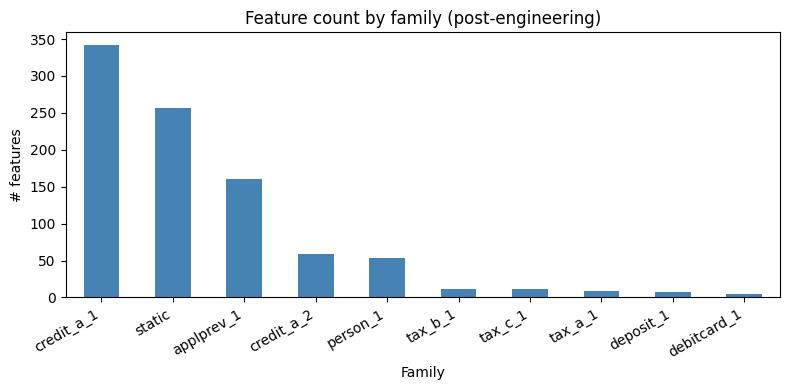


Top 10 features by NaN rate (from __missing indicators in X_bin):
maxannuity_4075009A__missing                        0.9499
equalitydataagreement_891L__missing                 0.9491
applprev_1_std_isdebitcard_527L__missing            0.9459
credit_a_1_max_prolongationcount_1120L__missing     0.9411
credit_a_1_std_contractsum_5085717L__missing        0.9356
person_1_max_housetype_905L__missing                0.9339
deposit_1_max_amount_416A__missing                  0.9315
debitcard_1_max_openingdate_857D__missing           0.9315
credit_a_1_std_annualeffectiverate_199L__missing    0.9254
assignmentdate_4527235D__missing                    0.9246


In [24]:
# ── 10.2 Field-family overview ───────────────────────────────────────────────────────────
# Group raw column names by their family prefix to summarise where the
# information lives. The first prefix component (split on '_') identifies
# the source table for aggregated columns; static / base columns get their
# own 'static' bucket.
import re
FAMILY_PREFIXES = {
    'applprev_1', 'tax_a_1', 'tax_b_1', 'tax_c_1',
    'credit_a_1', 'credit_b_1', 'credit_a_2', 'credit_b_2',
    'other_1', 'person_1', 'deposit_1', 'debitcard_1',
}

def family(col: str) -> str:
    base = col.split('__missing')[0]   # collapse missingness indicators into their source family
    for p in sorted(FAMILY_PREFIXES, key=len, reverse=True):
        if base.startswith(p + '_'):
            return p
    return 'static'

all_features = num_feature_names + bin_feature_names + cat_feature_names
fam_counts = pd.Series([family(c) for c in all_features]).value_counts().sort_values(ascending=False)
print('Feature count by family:')
print(fam_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
fam_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Feature count by family (post-engineering)')
ax.set_xlabel('Family')
ax.set_ylabel('# features')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_count_by_family.png', dpi=140)
plt.show()

# Top-10 raw columns by missingness, computed BEFORE the sentinel fill (use the
# saved __missing indicators in X_bin: indicator-mean equals raw NaN rate).
_missing_cols = [c for c in X_bin.columns if c.endswith('__missing')]
if _missing_cols:
    miss_rates = X_bin[_missing_cols].mean().sort_values(ascending=False).head(10)
    print('\nTop 10 features by NaN rate (from __missing indicators in X_bin):')
    print(miss_rates.round(4).to_string())
else:
    print('\nNo __missing indicators present (unexpected).')

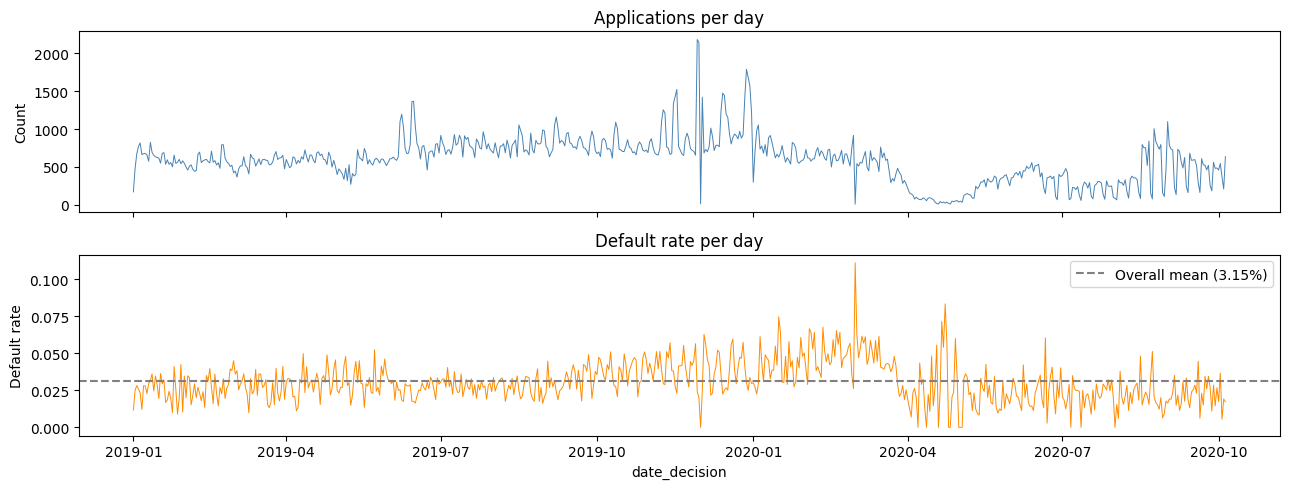

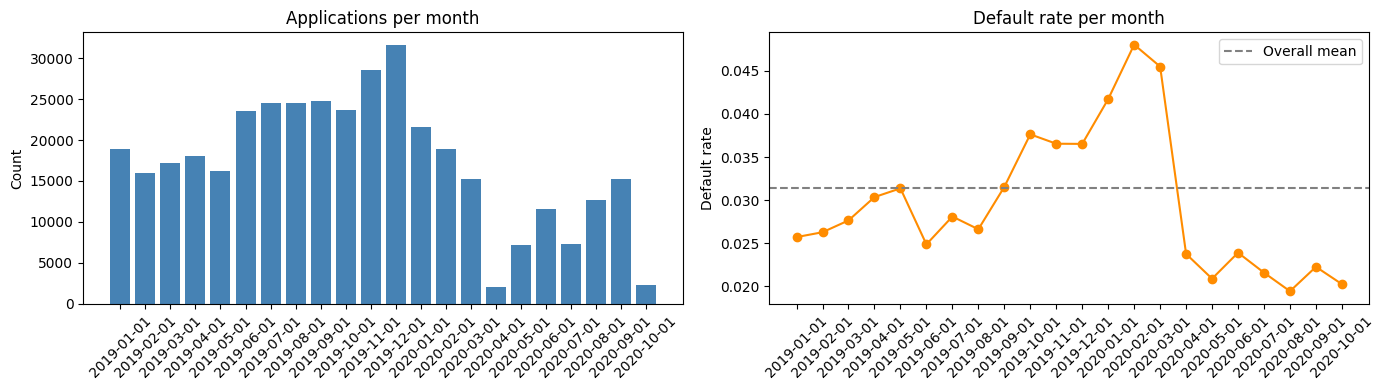

In [25]:
# ── 10.3 Temporal analysis ────────────────────────────────────────────────────────────────────
# The rolling-window experiment in notebook 01 partitions on this temporal axis;
# severe spikes or gaps would change how time steps should be defined.
daily = (
    pd.DataFrame({'date_decision': meta['date_decision'], 'y': Y})
    .groupby('date_decision')
    .agg(n_apps=('y', 'size'), default_rate=('y', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(daily['date_decision'], daily['n_apps'], color='steelblue', linewidth=0.7)
axes[0].set_title('Applications per day')
axes[0].set_ylabel('Count')
axes[1].plot(daily['date_decision'], daily['default_rate'], color='darkorange', linewidth=0.7)
axes[1].axhline(Y.mean(), color='grey', linestyle='--', label=f'Overall mean ({Y.mean():.2%})')
axes[1].set_title('Default rate per day')
axes[1].set_ylabel('Default rate')
axes[1].set_xlabel('date_decision')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'daily_apps_and_default_rate.png', dpi=140)
plt.show()

monthly = (
    pd.DataFrame({'month': pd.to_datetime(meta['date_decision']).dt.to_period('M').dt.to_timestamp(),
                  'y': Y})
    .groupby('month')
    .agg(n_apps=('y', 'size'), default_rate=('y', 'mean'))
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(monthly['month'].astype(str), monthly['n_apps'], color='steelblue')
axes[0].set_title('Applications per month')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(monthly['month'].astype(str), monthly['default_rate'], marker='o', color='darkorange')
axes[1].axhline(Y.mean(), color='grey', linestyle='--', label='Overall mean')
axes[1].set_title('Default rate per month')
axes[1].set_ylabel('Default rate')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'monthly_apps_and_default_rate.png', dpi=140)
plt.show()

Top 10 features by normalised mean difference (positive vs negative):
mindbddpdlast24m_3658935P                    1.0000
mindbdtollast24m_4525191P                    1.0000
avgmaxdpdlast9m_3716943P                     1.0000
credit_a_1_max_residualamount_488A           1.0000
credit_a_1_mean_residualamount_488A          1.0000
credit_a_1_max_numberofoverdueinstls_834L    1.0000
credit_a_1_min_overdueamount_31A             1.0000
assignmentdate_4527235D                      1.0000
applicationcnt_361L                          0.9999
credit_a_1_min_residualamount_488A           0.9098


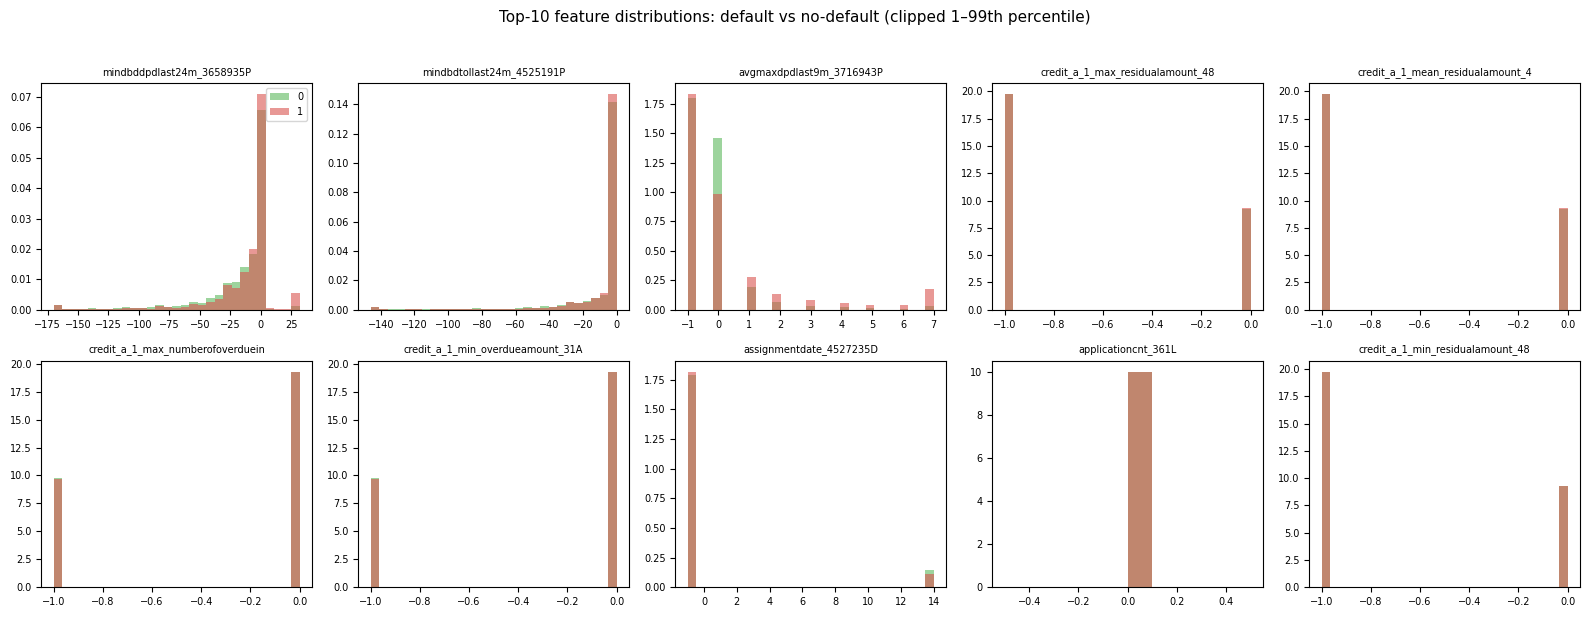

In [26]:
# ── 10.4 Feature distributions: top-10 by class separation ──────────────────────────────────────────
# Cheap proxy for predictive power: normalised mean difference between classes.
# We drop the __missing indicators from this view so it reflects feature signal
# rather than missingness signal.
_signal_cols = [c for c in X.columns if not c.endswith('__missing')]
X_eda = X[_signal_cols].copy()
X_eda['__y__'] = Y
means = X_eda.groupby('__y__').mean(numeric_only=True)
diff = ((means.loc[1] - means.loc[0]) / (means.loc[1].abs() + means.loc[0].abs() + 1e-9)).abs()
top10 = diff.sort_values(ascending=False).head(10)

print('Top 10 features by normalised mean difference (positive vs negative):')
print(top10.round(4).to_string())

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
for ax, feat in zip(axes, top10.index):
    vals0 = X_eda.loc[X_eda['__y__'] == 0, feat]
    vals1 = X_eda.loc[X_eda['__y__'] == 1, feat]
    q01 = X_eda[feat].quantile(0.01)
    q99 = X_eda[feat].quantile(0.99)
    if q99 > q01:
        bins = np.linspace(q01, q99, 30)
    else:
        bins = 10
    ax.hist(vals0.clip(lower=q01, upper=q99), bins=bins, alpha=0.6, label='0', color='#5cb85c', density=True)
    ax.hist(vals1.clip(lower=q01, upper=q99), bins=bins, alpha=0.6, label='1', color='#d9534f', density=True)
    ax.set_title(feat[:32], fontsize=7)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=7)
plt.suptitle('Top-10 feature distributions: default vs no-default (clipped 1–99th percentile)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'top10_feature_distributions.png', dpi=140)
plt.show()

Plotting default rate by category for: ['cardtype_51L', 'credtype_322L', 'disbursementtype_67L', 'equalitydataagreement_891L']


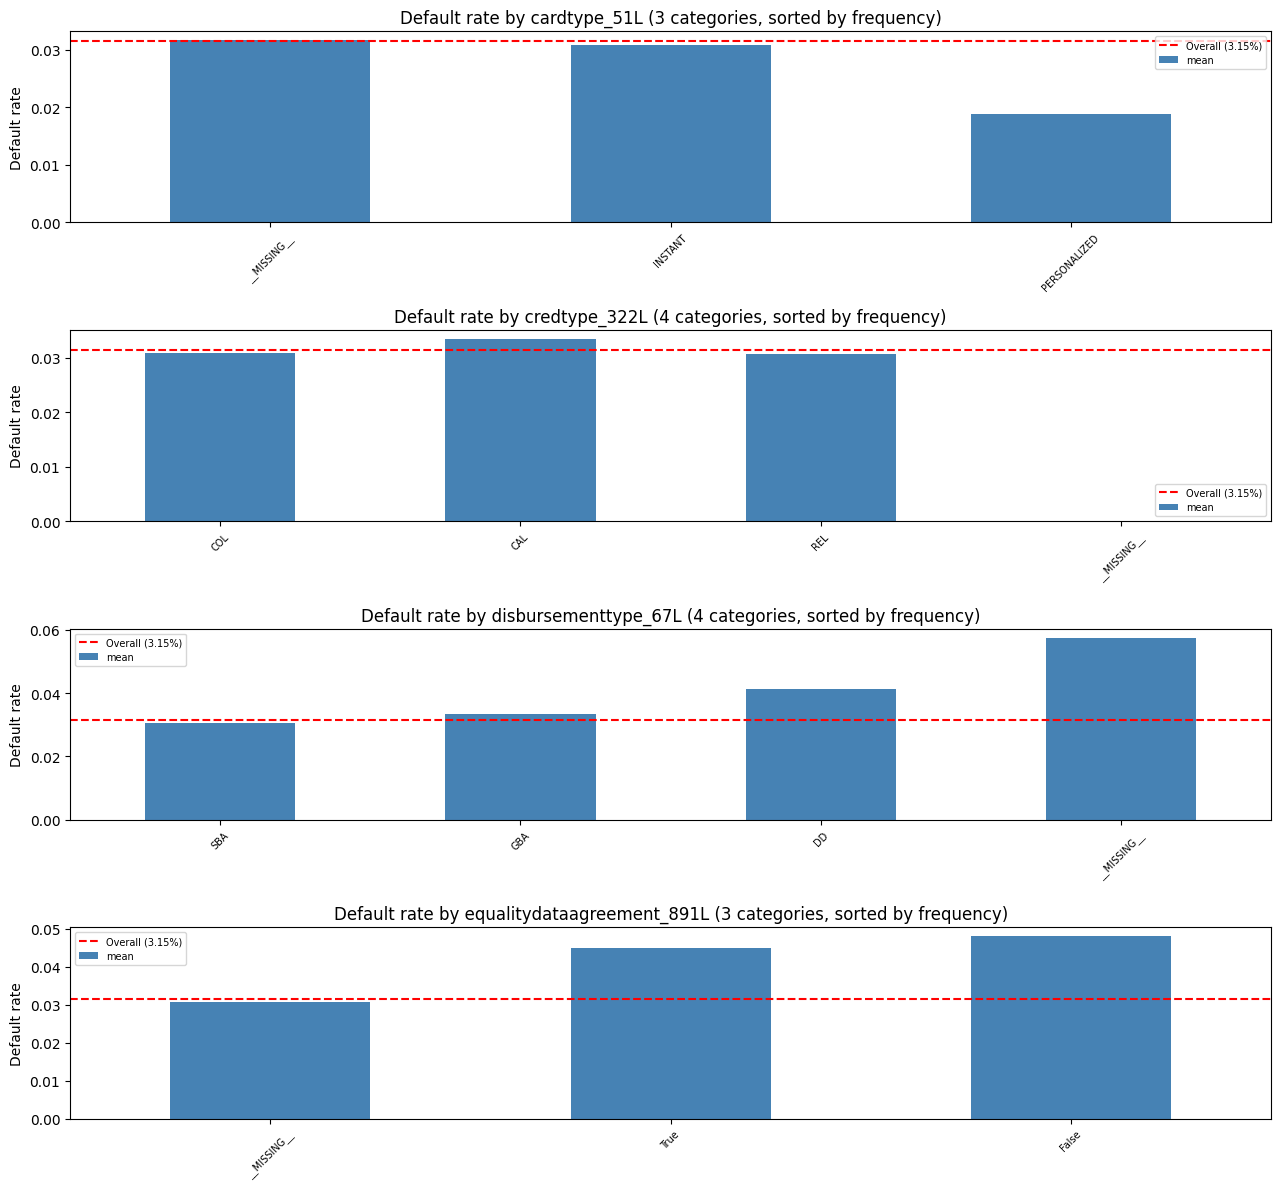

In [27]:
# ── 10.5 Default rate conditioned on a few categorical features ───────────────────────────────────────
# Pick up to 4 categorical columns with manageable cardinality and visualise
# how default rate varies across their categories. The >50-distinct-values
# drop in section 5 already removes the wildest-cardinality columns, but we
# still cap at MAX_CAT_CARDINALITY for readable plots.
MAX_CAT_CARDINALITY = 30
cat_for_plot = [c for c in cat_feature_names if X_cat[c].nunique() <= MAX_CAT_CARDINALITY][:4]

if not cat_for_plot:
    print('No categorical column with manageable cardinality found for the rate plot.')
else:
    print(f'Plotting default rate by category for: {cat_for_plot}')
    fig, axes = plt.subplots(len(cat_for_plot), 1, figsize=(13, 3 * len(cat_for_plot)))
    if len(cat_for_plot) == 1:
        axes = [axes]
    for ax, c in zip(axes, cat_for_plot):
        rate = pd.DataFrame({'cat': X_cat[c].values, 'y': Y}).groupby('cat')['y'].agg(['size', 'mean'])
        rate = rate.sort_values('size', ascending=False)
        rate['mean'].plot(kind='bar', ax=ax, color='steelblue')
        ax.axhline(Y.mean(), color='red', linestyle='--', label=f'Overall ({Y.mean():.2%})')
        ax.set_title(f'Default rate by {c} ({len(rate)} categories, sorted by frequency)')
        ax.set_ylabel('Default rate')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'default_rate_by_categorical.png', dpi=140)
    plt.show()